# CycleGAN Inference Demo

Dieses Notebook nutzt das neue `src.apply_cyclegan`-Modul, um einen gespeicherten Generator auf Testbilder anzuwenden. Es wählt zufällig 5 Eingabebilder aus, wendet den Generator auf sie an und speichert die Ergebnisse unter `results/cyclegan_inference_demo/<direction>` (der Ordnernamen entspricht dem mapping). Eine Beispielkombination wird anschließend nebeneinander angezeigt.

## Ablauf
1. Konfiguration und Checkpoint laden.
2. Ausgewählte Testbilder aus `data/night2day/night_to_day/testA` bzw. `testB` einlesen.
3. Den passenden Generator (`G` für day→night, `F` für night→day) anwenden.
4. Ergebnisse abspeichern und eine Referenzseite nebeneinander visualisieren.

Wenn du `direction = "night2day"` setzt, verwenden wir automatisch `testB` als Input und `F` als Generator; die Ausgaben landen dann unter `results/cyclegan_inference_demo/night2day`.

In [20]:
from pathlib import Path
import random
import torch
from matplotlib import pyplot as plt
from PIL import Image

from src.apply_cyclegan import (
    apply_generator,
    build_generator,
    build_inference_transform,
    gather_image_paths,
    find_checkpoint,
)
from src.utils.common import load_cfg

NUM_SAMPLES = 5  # Anzahl zufällig ausgewählter Bilder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = load_cfg("configs/cyclegan.yaml")


In [ ]:
direction = "nigth2day"  # Setze auf "night2day" für die Umkehrung
input_dir = Path("data/night2day/night_to_day/testA") if direction == "day2night" else Path("data/night2day/night_to_day/testB")
checkpoint = find_checkpoint("experiments/cyclegan_day2night_20251110_172804/epoch_0200.pt", cfg)
extensions = cfg["data"].get("extensions", ("jpg", "jpeg", "png", "bmp", "tif", "tiff"))
image_paths = gather_image_paths(input_dir, extensions)
assert image_paths, "Keine Testbilder gefunden."
sample_paths = random.sample(image_paths, min(NUM_SAMPLES, len(image_paths)))
transform = build_inference_transform(cfg)
generator = build_generator(cfg, device)
state = torch.load(checkpoint, map_location="cpu")
key = "G" if direction == "day2night" else "F"
generator.load_state_dict(state[key])
output_dir = Path("results/cyclegan_inference_demo") / direction
apply_generator(
    generator,
    sample_paths,
    transform,
    output_dir,
    input_dir,
    device,
)
print(f"Speicherort der generierten Bilder: {output_dir}")


/srv/store/docker-users/thesis/khajuria/day2night/src/models/cyclegan.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location=


5 images saved to results/cyclegan_inference_demo/day2night
Speicherort der generierten Bilder: results/cyclegan_inference_demo/day2night


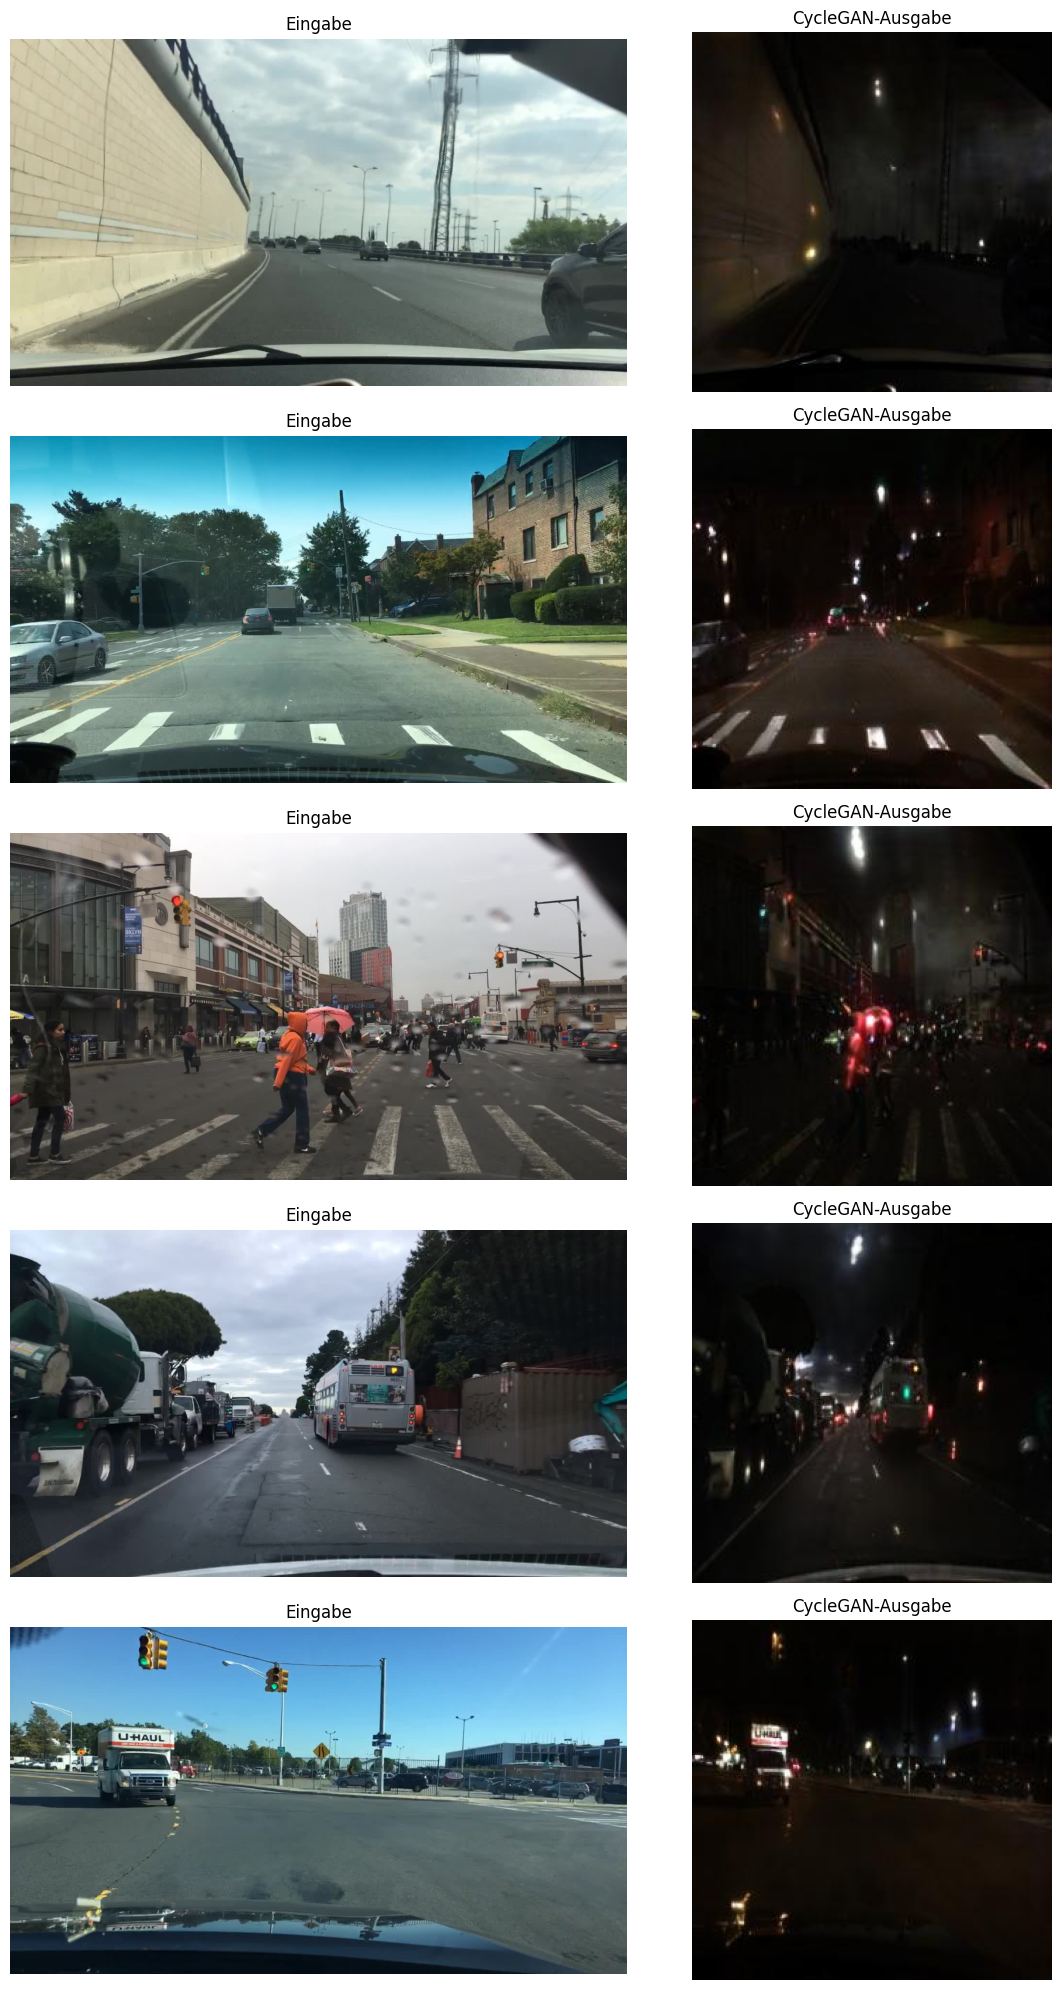

In [22]:
def show_samples(input_paths, output_dir):
    rows = max(1, len(input_paths))
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
    axes = axes.reshape(rows, 2)
    for row_idx, input_path in enumerate(input_paths):
        output_path = output_dir / input_path.relative_to(input_dir)
        for col_idx, (path, title) in enumerate((
            (input_path, "Eingabe"),
            (output_path, "CycleGAN-Ausgabe"),
        )):
            ax = axes[row_idx, col_idx]
            ax.imshow(Image.open(path))
            ax.set_title(title)
            ax.axis("off")
    plt.tight_layout()

show_samples(sample_paths, output_dir)


In [23]:
print('Größen der Eingangsbilder und deren CycleGAN-Ausgaben:')
for input_path in sample_paths:
    output_path = output_dir / input_path.relative_to(input_dir)
    input_size = Image.open(input_path).size
    output_size = Image.open(output_path).size
    print(f'{input_path.name}: input={input_size}  output={output_size}')


Größen der Eingangsbilder und deren CycleGAN-Ausgaben:
97592598-ebef220e.jpg: input=(1280, 720)  output=(256, 256)
1ac141cf-7c4ac16f.jpg: input=(1280, 720)  output=(256, 256)
0ead45b1-cc3c9a49.jpg: input=(1280, 720)  output=(256, 256)
59d556ec-0dcbb633.jpg: input=(1280, 720)  output=(256, 256)
0aab8fd1-73261fe4.jpg: input=(1280, 720)  output=(256, 256)


### Hinweise
- Die generierten Bilder stehen unter `results/cyclegan_inference_demo/day2night` oder `.../night2day`.
- Der verwendete Checkpoint ist `experiments/cyclegan_day2night_20251110_163433/epoch_0140.pt`.
- Du kannst `direction` ändern, um das night→day-Mapping zu nutzen; das Notebook wechselt dann automatisch zu `testB` und zum Generator `F`.
- Das `apply_generator`-Modul sichert die Eingaben/Ausgaben recht ähnlich zur CLI, sodass du dich auf den Ordner `results/cyclegan_inference_demo/<direction>` verlassen kannst.